In [7]:
import pandas as pd
import numpy as np
import os

# DATA LOADING
print("Data Loading")
data_dir = '.' 
train_data_path = os.path.join(data_dir, 'train_data.csv')
train_labels_path = os.path.join(data_dir, 'train_labels.csv')

# Load data (using nrows to avoid Out-Of-Memory errors)
df_data = pd.read_csv(train_data_path, nrows=10000)
df_labels = pd.read_csv(train_labels_path)

# Merge data and labels to create one complete dataset
df = df_data.merge(df_labels, on='customer_ID', how='inner')

# Count Rows and Features 
num_rows, num_cols = df.shape
print(f"\nTotal Rows (Data Points): {num_rows}")
# Subtracting 3 to ignore non-predictive columns: customer_ID, S_2 (Date), and target
print(f"Total Predictive Features: {num_cols - 3}")

# Check Missing Values
total_missing = df.isnull().sum().sum()
print(f"Total Missing Values in Dataset: {total_missing}")


# FEATURE SUMMARY TABLE
print("\nFeature Summary Table")
feature_summary = []

for col in df.columns:
    # Skip ID, Date, and Target for the feature table
    if col in ['customer_ID', 'S_2', 'target']:
        continue
        
    dtype = df[col].dtype
    missing_count = df[col].isnull().sum()
    
    # Logic to separate Categorical from Numerical
    if dtype == 'object' or df[col].nunique() < 20:
        cat_type = 'Categorical'
        # Grab up to the first 5 unique values to show as an example
        unique_vals = [str(x) for x in df[col].dropna().unique()[:5]]
        values_str = ", ".join(unique_vals)
        if df[col].nunique() > 5:
            values_str += ", ..."
    else:
        cat_type = 'Numerical'
        values_str = f"Range: [{df[col].min():.2f}, {df[col].max():.2f}]"
        
    feature_summary.append({
        'Feature': col,
        'Type': cat_type,
        'Values': values_str,
        'Missing Values': missing_count
    })

summary_table = pd.DataFrame(feature_summary)
# displays the table
display(summary_table.head(15)) 


# OUTLIER DETECTION
print("Outlier Detection ")
# Find outliers for the first 5 numerical columns using the IQR method
numerical_cols = summary_table[summary_table['Type'] == 'Numerical']['Feature'].tolist()

print("Outlier Count (Sample of first 5 numerical features):")
for col in numerical_cols[:5]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f" - {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}% of data)")


# TARGET VARIABLE & CLASS IMBALANCE
print("\nTarget Variable Analysis")
print("Task Type: Classification")

# How is it encoded?
target_classes = sorted(df['target'].dropna().unique().tolist())
print(f"Target is encoded as: {target_classes} (0 = Paid, 1 = Defaulted)")

# Class Imbalance Check
class_counts = df['target'].value_counts(normalize=True) * 100
print("\nClass Imbalance (Percentage of dataset):")
for class_val, pct in class_counts.items():
    print(f" - Class {class_val}: {pct:.2f}%")

Data Loading

Total Rows (Data Points): 10000
Total Predictive Features: 188
Total Missing Values in Dataset: 288362

Feature Summary Table


,Feature,Type,Values,Missing Values
0,P_2,Numerical,"Range: [-0.26, 1.01]",64
1,D_39,Numerical,"Range: [0.00, 4.27]",0
2,B_1,Numerical,"Range: [-0.14, 1.32]",0
3,B_2,Numerical,"Range: [0.00, 1.01]",0
4,R_1,Numerical,"Range: [0.00, 2.26]",0
5,S_3,Numerical,"Range: [-0.15, 1.80]",1752
6,D_41,Numerical,"Range: [0.00, 2.59]",0
7,B_3,Numerical,"Range: [0.00, 1.26]",0
8,D_42,Numerical,"Range: [0.00, 2.56]",8645
9,D_43,Numerical,"Range: [0.00, 2.32]",3087


Outlier Detection 
Outlier Count (Sample of first 5 numerical features):
 - P_2: 36 outliers (0.4% of data)
 - D_39: 769 outliers (7.7% of data)
 - B_1: 1439 outliers (14.4% of data)
 - B_2: 0 outliers (0.0% of data)
 - R_1: 1210 outliers (12.1% of data)

Target Variable Analysis
Task Type: Classification
Target is encoded as: [0, 1] (0 = Paid, 1 = Defaulted)

Class Imbalance (Percentage of dataset):
 - Class 0: 74.47%
 - Class 1: 25.53%


Categorical Features (Proportional Tables)
Showing the percentage of Class 1 (Default) vs Class 0 (Paid) for each category.

Feature: D_63


,Class 0 (Paid) %,Class 1 (Default) %
D_63,,
CL,74.20,25.80
CO,72.45,27.55
CR,84.00,16.00
XL,68.18,31.82
XM,28.57,71.43
XZ,75.38,24.62


Feature: D_64


,Class 0 (Paid) %,Class 1 (Default) %
D_64,,
-1,75.95,24.05
O,83.40,16.60
R,68.01,31.99
U,62.16,37.84


Feature: D_66


...

Feature: D_68


,Class 0 (Paid) %,Class 1 (Default) %
D_68,,
0.0,100.00,0.00
1.0,61.11,38.89
2.0,52.45,47.55
3.0,59.08,40.92
4.0,64.91,35.09
5.0,74.60,25.40
6.0,81.57,18.43


Feature: B_30


,Class 0 (Paid) %,Class 1 (Default) %
B_30,,
0.0,80.89,19.11
1.0,40.23,59.77
2.0,43.48,56.52



 Numerical Features (Normalized Density Histograms)
Density = 1. The area under the curve for Class 0 equals 1, and Class 1 equals 1.


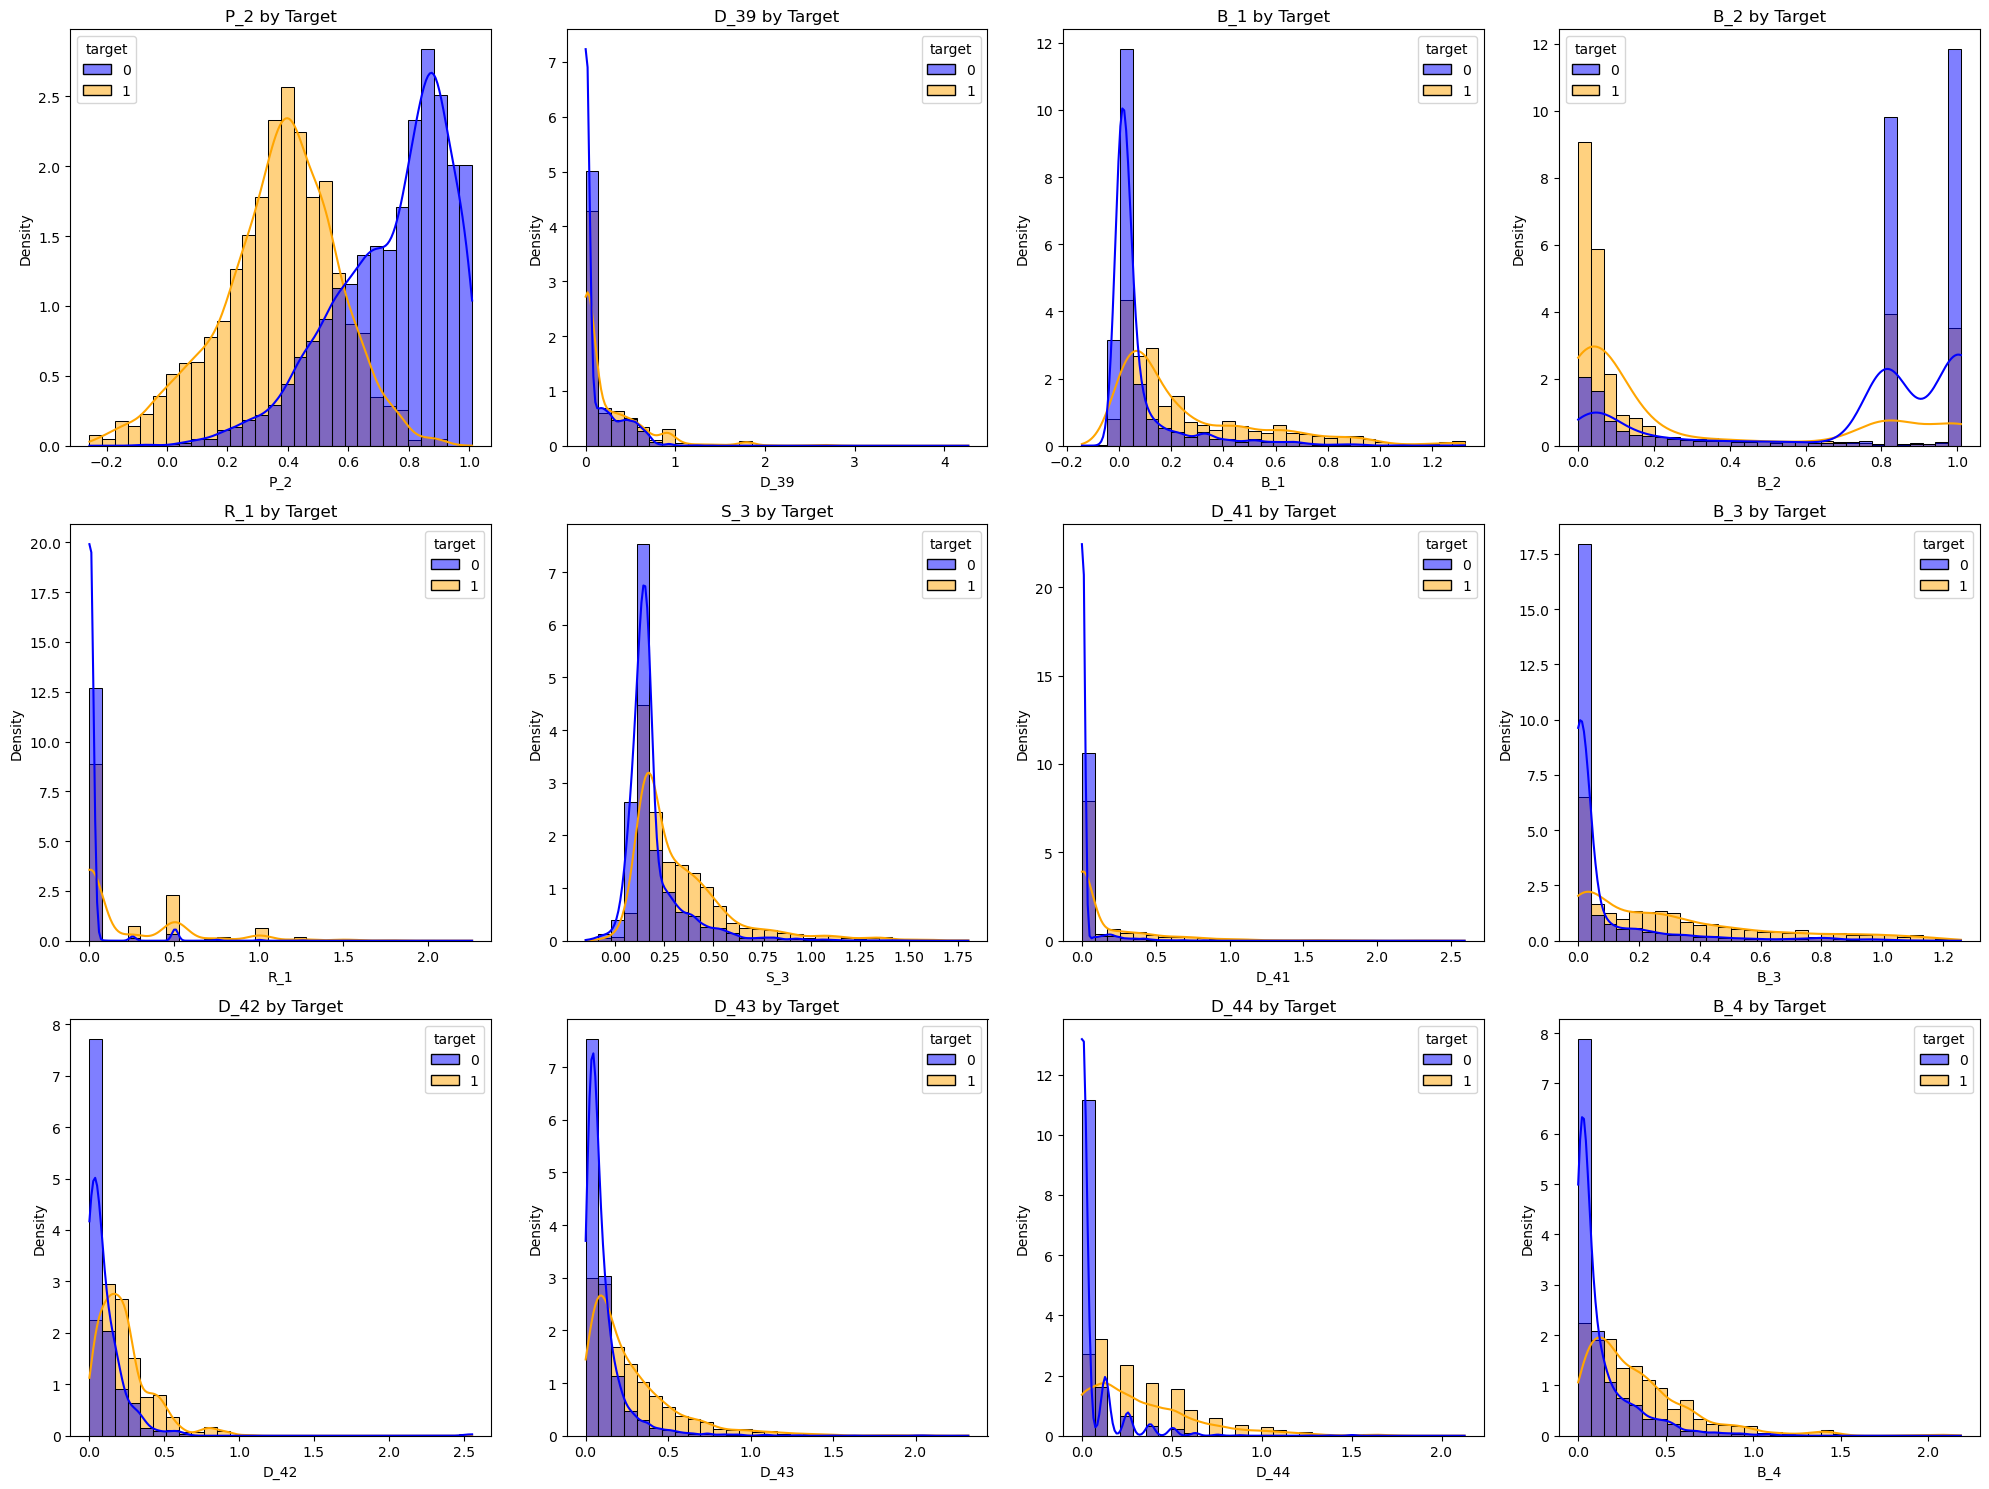

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore warning messages about layout for cleaner output
warnings.filterwarnings('ignore')

# DATA VISUALIZATION: FEATURE VS TARGET

# Separate features based on the summary table logic we used earlier
features = [col for col in df.columns if col not in ['customer_ID', 'S_2', 'target']]
categorical_cols = [col for col in features if df[col].dtype == 'object' or df[col].nunique() < 20]
numerical_cols = [col for col in features if col not in categorical_cols]

# CATEGORICAL FEATURES (Presented as Tables)
print("Categorical Features (Proportional Tables)")
print("Showing the percentage of Class 1 (Default) vs Class 0 (Paid) for each category.\n")

for col in categorical_cols[:5]: # Showing first 5 for brevity
    # Create a cross-tabulation table normalized by the index (rows sum to 100%)
    crosstab = pd.crosstab(df[col], df['target'], normalize='index') * 100
    crosstab.columns = ['Class 0 (Paid) %', 'Class 1 (Default) %']
    
    print(f"Feature: {col}")
    display(crosstab.round(2))

# NUMERICAL FEATURES (Normalized Histograms)
print("\n Numerical Features (Normalized Density Histograms)")
print("Density = 1. The area under the curve for Class 0 equals 1, and Class 1 equals 1.")

# Select the first 12 numerical features to plot
features_to_plot = numerical_cols[:12]

# Set up the matplotlib grid
fig = plt.figure(figsize=(20, 15))

for i, col in enumerate(features_to_plot):
    plt.subplot(3, 4, i + 1)
    
    # Plot normalized histograms
    # stat='density' ensures the total area of the histogram is 1
    # common_norm=False ensures the two classes are normalized independently
    sns.histplot(
        data=df, 
        x=col, 
        hue='target', 
        stat='density', 
        common_norm=False, 
        bins=30, 
        alpha=0.5, 
        kde=True,
        palette={0: 'blue', 1: 'orange'}
    )
    
    plt.title(f'{col} by Target')
    plt.xlabel(col)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

Cleaning Missing Values
   - Dropped 23 columns with >75% missing data.
   - Imputed remaining numericals with Median and categoricals with 'Unknown'.

 Rescaling Numerical Features
   - Strategy: RobustScaler (Resistant to the outliers we found earlier).

 One-Hot Encoding Categorical Features
   - Dataset went from 191 to 198 columns.

Before & After Visualization


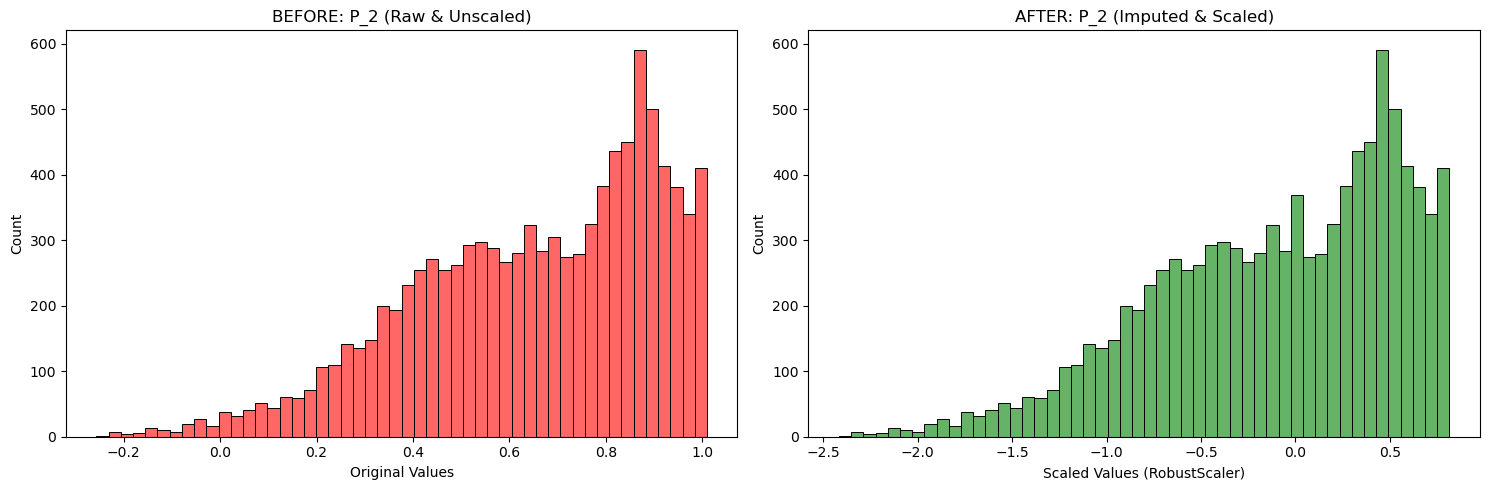

Notice how the 'After' distribution fills in the gaps (due to median imputation)
and the X-axis is now centered around 0 with a much tighter range (due to scaling),
making it perfectly formatted for machine learning models!


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import warnings
warnings.filterwarnings('ignore')

# DATA CLEANING & PREPARATION"

# Make a copy of the original data for our "Before" visualization later
df_original = df.copy()

# Identify feature types
features = [col for col in df.columns if col not in ['customer_ID', 'S_2', 'target']]
categorical_cols = [col for col in features if df[col].dtype == 'object' or df[col].nunique() < 20]
numerical_cols = [col for col in features if col not in categorical_cols]


# DATA CLEANING (Missing Values)
print("Cleaning Missing Values")

# Drop columns with > 75% missing data
threshold = 0.75
missing_fractions = df[features].isnull().mean()
cols_to_drop = missing_fractions[missing_fractions > threshold].index.tolist()
df = df.drop(columns=cols_to_drop)

# Update our feature lists after dropping
numerical_cols = [c for c in numerical_cols if c not in cols_to_drop]
categorical_cols = [c for c in categorical_cols if c not in cols_to_drop]
print(f"   - Dropped {len(cols_to_drop)} columns with >75% missing data.")

# Impute Numerical with Median
for col in numerical_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Impute Categorical with 'Unknown'
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')
    # Ensure they are treated as strings for the encoder
    df[col] = df[col].astype(str) 

print("   - Imputed remaining numericals with Median and categoricals with 'Unknown'.")


# RESCALING NUMERICAL FEATURES
print("\n Rescaling Numerical Features")
print("   - Strategy: RobustScaler (Resistant to the outliers we found earlier).")

scaler = RobustScaler()
# Fit and transform the numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])


# ONE-HOT ENCODING CATEGORICAL FEATURES
print("\n One-Hot Encoding Categorical Features")

# Use get_dummies. drop_first=True prevents multicollinearity (the dummy variable trap)
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"   - Dataset went from {df_original.shape[1]} to {df.shape[1]} columns.")


# VISUALIZATION: BEFORE VS AFTER
print("\nBefore & After Visualization")

# Pick a numerical feature that had missing values to visualize the transformation
# (Finding the first numerical column that had missing values in the original data)
feature_to_plot = next(col for col in numerical_cols if df_original[col].isnull().sum() > 0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# BEFORE PLOT
sns.histplot(df_original[feature_to_plot].dropna(), bins=50, ax=axes[0], color='red', alpha=0.6)
axes[0].set_title(f"BEFORE: {feature_to_plot} (Raw & Unscaled)")
axes[0].set_xlabel("Original Values")
axes[0].set_ylabel("Count")

# AFTER PLOT
sns.histplot(df[feature_to_plot], bins=50, ax=axes[1], color='green', alpha=0.6)
axes[1].set_title(f"AFTER: {feature_to_plot} (Imputed & Scaled)")
axes[1].set_xlabel("Scaled Values (RobustScaler)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("Notice how the 'After' distribution fills in the gaps (due to median imputation)")
print("and the X-axis is now centered around 0 with a much tighter range (due to scaling),")
print("making it perfectly formatted for machine learning models!")

In [10]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

#MACHINE LEARNING & EVALUATION

# PROBLEM FORMULATION & SPLITTING
print("Formulating Problem and Splitting Data")

# Drop identifier columns and the target to create our Features (X)
# Note: One-hot encoded original columns were already dropped by pd.get_dummies()
X = df.drop(columns=['customer_ID', 'S_2', 'target'])
y = df['target']

# Split 1: Separate out a 10% Test set
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.10, random_state=42, stratify=y)

# Split 2: Split the remaining 90% into Train and Validation (80/20 split of the temp set)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.20, random_state=42, stratify=y_temp)

print(f"   - Training Data:   {X_train.shape[0]} rows")
print(f"   - Validation Data: {X_val.shape[0]} rows")
print(f"   - Test Data:       {X_test.shape[0]} rows")


# TRAIN ML ALGORITHM
print("\n Training Logistic Regression Model")
# Using max_iter=1000 to ensure the math converges properly
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)


# EVALUATE PERFORMANCE (Validation & Test)
print("\nEvaluating Performance")

# Predict probabilities (we need probabilities, not just 0/1, for the Amex Metric)
val_preds_proba = model.predict_proba(X_val)[:, 1]
val_preds_class = model.predict(X_val)

print("Standard Metrics (Validation) ")
print(f"Accuracy: {accuracy_score(y_val, val_preds_class):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_val, val_preds_proba):.4f}")

#  Official Amex Kaggle Metric Function 
def amex_metric(y_true, y_pred):
    """The official Kaggle Evaluation Metric for Amex Default Prediction"""
    labels = np.transpose(np.array([y_true, y_pred]))
    labels = labels[labels[:, 1].argsort()[::-1]]
    weights = np.where(labels[:,0]==0, 20, 1)
    cut_vals = labels[np.cumsum(weights) <= int(0.04 * np.sum(weights))]
    top_four = np.sum(cut_vals[:,0]) / np.sum(labels[:,0])
    gini = [0,0]
    for i in [1,0]:
        labels = np.transpose(np.array([y_true, y_pred]))
        labels = labels[labels[:, i].argsort()[::-1]]
        weight = np.where(labels[:,0]==0, 20, 1)
        weight_random = np.cumsum(weight / np.sum(weight))
        total_pos = np.sum(labels[:, 0] * weight)
        cum_pos_found = np.cumsum(labels[:, 0] * weight)
        lorentz = cum_pos_found / total_pos
        gini[i] = np.sum((lorentz - weight_random) * weight)
    return 0.5 * (gini[1]/gini[0] + top_four)

# Calculate Amex Score
amex_score = amex_metric(y_val.values, val_preds_proba)
print(f"AMEX Kaggle Score: {amex_score:.4f} (0.0 is worst, 1.0 is perfect)")


# APPLY TO CHALLENGE TEST SET & SUBMIT
print("\n Generating Kaggle Submission File...")

data_dir = '.' 
test_data_path = os.path.join(data_dir, 'test_data.csv')

if not os.path.exists(test_data_path):
    print("'test_data.csv' not found. Skipping submission generation.")
else:
    df_test_raw = pd.read_csv(test_data_path, nrows=10000)
    
    # Save the IDs for the final submission file
    test_ids = df_test_raw['customer_ID']
    
    # Clean Test Data EXACTLY how we cleaned Training Data
    # 1. Drop the same columns
    cols_to_drop = [c for c in df_test_raw.columns if c not in df_original.columns]
    df_test = df_test_raw.drop(columns=['customer_ID', 'S_2'] + cols_to_drop, errors='ignore')
    
    # Impute missing values (using same median/Unknown logic)
    for col in numerical_cols:
        if col in df_test.columns:
            df_test[col] = df_test[col].fillna(df_original[col].median())
            
    for col in categorical_cols:
        if col in df_test.columns:
            df_test[col] = df_test[col].fillna('Unknown').astype(str)
            
    # One-Hot Encode
    df_test = pd.get_dummies(df_test, columns=[c for c in categorical_cols if c in df_test.columns], drop_first=True)
    
    # Align Columns 
    # The test set might lack some categories the training set had. 
    # This ensures the test data has the exact same columns as X_train, filling missing ones with 0.
    df_test = df_test.reindex(columns=X_train.columns, fill_value=0)
    
    #vScale using the already fitte scaler
    df_test[numerical_cols] = scaler.transform(df_test[numerical_cols])
    
    # Generate Predictions
    test_predictions = model.predict_proba(df_test)[:, 1]
    
    # Create Submission DataFrame
    submission = pd.DataFrame({
        'customer_ID': test_ids,
        'prediction': test_predictions
    })
    
    # Save to CSV
    submission.to_csv('submission.csv', index=False)
    print(" 'submission.csv' has been generated")

Formulating Problem and Splitting Data
   - Training Data:   7200 rows
   - Validation Data: 1800 rows
   - Test Data:       1000 rows

 Training Logistic Regression Model

Evaluating Performance
Standard Metrics (Validation) 
Accuracy: 0.8872
ROC-AUC:  0.9561
AMEX Kaggle Score: 0.7648 (0.0 is worst, 1.0 is perfect)

 Generating Kaggle Submission File...
 'submission.csv' has been generated
